claude


In [ ]:
import os, glob, cv2, numpy as np, pandas as pd, matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Conv2DTranspose, concatenate,
    BatchNormalization, Activation, SpatialDropout2D, Add, multiply
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, CSVLogger, LearningRateScheduler




)

IMG_SIZE = 256
dataset_path = "/content/drive/MyDrive/archive (8)/kaggle_3m"
save_dir = "/content/drive/MyDrive/brain_tumor_segmentation_results"
os.makedirs(save_dir, exist_ok=True)

In [ ]:
all_tif_files = glob.glob(dataset_path + "/**/*.tif", recursive=True)
image_paths, mask_paths = [], []
for f in all_tif_files:
    if "_mask" not in f:
        m = f.replace(".tif", "_mask.tif")
        if os.path.exists(m):
            image_paths.append(f)
            mask_paths.append(m)
paired = sorted(zip(image_paths, mask_paths))
image_paths = [p[0] for p in paired]
mask_paths = [p[1] for p in paired]
print("Total paired images:", len(image_paths))

Total paired images: 3929


In [ ]:
def load_image_and_mask(img_path, mask_path, img_size=IMG_SIZE):
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (img_size, img_size), interpolation=cv2.INTER_AREA)
    image = (image / 255.0).astype(np.float32)

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    # INTER_NEAREST is mandatory for masks -- linear/area interpolation
    # blurs the 0/255 edge and corrupts the ground truth boundary.
    mask = cv2.resize(mask, (img_size, img_size), interpolation=cv2.INTER_NEAREST)
    mask = (mask > 0).astype(np.float32)
    mask = np.expand_dims(mask, axis=-1)
    return image, mask

def load_dataset(image_list, mask_list, img_size=IMG_SIZE):
    imgs, msks = [], []
    for ip, mp in zip(image_list, mask_list):
        i, m = load_image_and_mask(ip, mp, img_size)
        imgs.append(i); msks.append(m)
    return np.array(imgs, dtype=np.float32), np.array(msks, dtype=np.float32)

In [ ]:
image_level_labels = np.array([
    1 if np.sum(cv2.imread(m, cv2.IMREAD_GRAYSCALE)) > 0 else 0
    for m in mask_paths
])

trainval_img, test_img, trainval_msk, test_msk, trainval_lbl, test_lbl = train_test_split(
    image_paths, mask_paths, image_level_labels,
    test_size=0.2, random_state=42, stratify=image_level_labels
)
train_img, val_img, train_msk, val_msk, train_lbl, val_lbl = train_test_split(
    trainval_img, trainval_msk, trainval_lbl,
    test_size=0.2, random_state=42, stratify=trainval_lbl
)

In [ ]:
# Keep ALL tumour-positive slices, but downsample empty-mask slices
# (2:1 negative:positive instead of the natural ~2.7:1 in this dataset
# -- adjust the ratio if you still see the model collapsing to background)
train_img = np.array(train_img); train_msk = np.array(train_msk); train_lbl = np.array(train_lbl)

pos_idx = np.where(train_lbl == 1)[0]
neg_idx = np.where(train_lbl == 0)[0]
rng = np.random.default_rng(42)
neg_keep = rng.choice(neg_idx, size=min(len(neg_idx), 2 * len(pos_idx)), replace=False)
keep_idx = np.concatenate([pos_idx, neg_keep])
rng.shuffle(keep_idx)

train_img = list(train_img[keep_idx])
train_msk = list(train_msk[keep_idx])
print("Rebalanced training set:", len(train_img),
      "( positive:", len(pos_idx), ", negative kept:", len(neg_keep), ")")

X_train, y_train = load_dataset(train_img, train_msk)
X_val,   y_val   = load_dataset(val_img,   val_msk)
X_test,  y_test  = load_dataset(test_img,  test_msk)
print("X_train:", X_train.shape, "X_val:", X_val.shape, "X_test:", X_test.shape)

Rebalanced training set: 2514 ( positive: 878 , negative kept: 1636 )
X_train: (2514, 256, 256, 3) X_val: (629, 256, 256, 3) X_test: (786, 256, 256, 3)


In [ ]:
def augment(image, mask):
    # geometric augments applied identically to image + mask
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask  = tf.image.flip_left_right(mask)
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_up_down(image)
        mask  = tf.image.flip_up_down(mask)
    k = tf.random.uniform((), maxval=4, dtype=tf.int32)
    image = tf.image.rot90(image, k)
    mask  = tf.image.rot90(mask, k)

    # photometric augments -- image only
    image = tf.image.random_brightness(image, 0.1)
    image = tf.image.random_contrast(image, 0.9, 1.1)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, mask

BATCH_SIZE = 16

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(len(X_train)).map(augment, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (
        tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth
    )

def iou_metric(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    union = tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

def focal_tversky_loss(y_true, y_pred, alpha=0.3, beta=0.7, gamma=0.75, smooth=1e-6):
    # alpha weights false positives, beta weights false negatives.
    # beta > alpha  ->  model is penalised more for MISSING tumour pixels,
    # which is what you want when the positive class is ~1-2% of pixels.
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    tp = tf.keras.backend.sum(y_true_f * y_pred_f)
    fn = tf.keras.backend.sum(y_true_f * (1 - y_pred_f))
    fp = tf.keras.backend.sum((1 - y_true_f) * y_pred_f)
    tversky = (tp + smooth) / (tp + alpha * fp + beta * fn + smooth)
    return tf.keras.backend.pow((1 - tversky), gamma)

def combo_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return 0.5 * tf.reduce_mean(bce) + 0.5 * focal_tversky_loss(y_true, y_pred)

In [ ]:
def conv_block(x, filters, dropout_rate=0.0):
    x = Conv2D(filters, 3, padding="same", kernel_regularizer=l2(1e-5))(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Conv2D(filters, 3, padding="same", kernel_regularizer=l2(1e-5))(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    if dropout_rate > 0:
        x = SpatialDropout2D(dropout_rate)(x)
    return x

def attention_gate(x, g, filters):
    # x: skip connection from encoder, g: gating signal from decoder (coarser)
    theta_x = Conv2D(filters, 1, padding="same")(x)
    phi_g = Conv2D(filters, 1, padding="same")(g)
    add = Activation("relu")(Add()([theta_x, phi_g]))
    psi = Conv2D(1, 1, padding="same", activation="sigmoid")(add)
    return multiply([x, psi])

def build_attention_unet(input_shape):
    inputs = Input(input_shape)

    c1 = conv_block(inputs, 32); p1 = MaxPooling2D()(c1)
    c2 = conv_block(p1, 64);     p2 = MaxPooling2D()(c2)
    c3 = conv_block(p2, 128, 0.1); p3 = MaxPooling2D()(c3)
    c4 = conv_block(p3, 256, 0.2); p4 = MaxPooling2D()(c4)

    bridge = conv_block(p4, 512, 0.3)

    u4 = Conv2DTranspose(256, 2, strides=2, padding="same")(bridge)
    a4 = attention_gate(c4, u4, 128)
    u4 = concatenate([u4, a4]); c5 = conv_block(u4, 256, 0.2)

    u3 = Conv2DTranspose(128, 2, strides=2, padding="same")(c5)
    a3 = attention_gate(c3, u3, 64)
    u3 = concatenate([u3, a3]); c6 = conv_block(u3, 128, 0.1)

    u2 = Conv2DTranspose(64, 2, strides=2, padding="same")(c6)
    a2 = attention_gate(c2, u2, 32)
    u2 = concatenate([u2, a2]); c7 = conv_block(u2, 64)

    u1 = Conv2DTranspose(32, 2, strides=2, padding="same")(c7)
    a1 = attention_gate(c1, u1, 16)
    u1 = concatenate([u1, a1]); c8 = conv_block(u1, 32)

    outputs = Conv2D(1, 1, activation="sigmoid")(c8)
    return Model(inputs, outputs, name="attention_unet")

model = build_attention_unet((IMG_SIZE, IMG_SIZE, 3))

In [ ]:
EPOCHS = 100
steps_per_epoch = len(X_train) // BATCH_SIZE

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=steps_per_epoch * EPOCHS,
    alpha=1e-5 / 1e-3  # decays down to 1e-5, never fully flatlines early
)

model.compile(
    optimizer=AdamW(learning_rate=lr_schedule, weight_decay=1e-5),
    loss=combo_loss,
    metrics=[dice_coef, iou_metric, "accuracy"]
)

best_model_path = os.path.join(save_dir, "best_attention_unet.keras")
history_csv_path = os.path.join(save_dir, "attention_unet_history.csv")

callbacks = [
    ModelCheckpoint(best_model_path, monitor="val_dice_coef", mode="max",
                     save_best_only=True, verbose=1),
    EarlyStopping(monitor="val_dice_coef", mode="max", patience=15,
                   restore_best_weights=True, verbose=1),
    CSVLogger(history_csv_path),
]

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/100
157/158 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9951 - dice_coef: 0.7604 - iou_metric: 0.6227 - loss: 0.1839
Epoch 1: val_dice_coef improved from 0.77153 to 0.78346, saving model to /content/drive/MyDrive/brain_tumor_segmentation_results/best_attention_unet.keras

Epoch 1: finished saving model to /content/drive/MyDrive/brain_tumor_segmentation_results/best_attention_unet.keras
158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.9952 - dice_coef: 0.7564 - iou_metric: 0.6195 - loss: 0.1871 - val_accuracy: 0.9961 - val_dice_coef: 0.7835 - val_iou_metric: 0.6595 - val_loss: 0.1735
Epoch 2/100
157/158 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9956 - dice_coef: 0.7719 - iou_metric: 0.6388 - loss: 0.1783
Epoch 2: val_dice_coef did not improve from 0.78346
158/158 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.9954 - dice_coef: 0.7692 - iou_metric: 0.6348 - loss: 0.1796 - val_accuracy: 0.9958 - val_dice_coef: 0.7723 - val_iou_metric: 0.6459 - val_loss: 0.1698
E

In [ ]:
def per_image_dice_iou(y_true, y_pred, threshold=0.5, smooth=1e-6):
    dices, ious = [], []
    for i in range(len(y_true)):
        yt = y_true[i].flatten()
        yp = (y_pred[i].flatten() > threshold).astype(np.float32)
        inter = np.sum(yt * yp)
        dice = (2 * inter + smooth) / (np.sum(yt) + np.sum(yp) + smooth)
        union = np.sum(yt) + np.sum(yp) - inter
        iou = (inter + smooth) / (union + smooth)
        dices.append(dice); ious.append(iou)
    return np.array(dices), np.array(ious)

test_pred = model.predict(X_test, batch_size=BATCH_SIZE)
dices, ious = per_image_dice_iou(y_test, test_pred)

# report separately for tumour-containing vs empty test slices --
# this is the number reviewers/markers actually want to see
has_tumour = np.array([np.sum(y_test[i]) > 0 for i in range(len(y_test))])
print(f"Mean Dice (all test images):        {dices.mean():.4f}")
print(f"Mean Dice (tumour-positive only):   {dices[has_tumour].mean():.4f}")
print(f"Mean IoU  (tumour-positive only):   {ious[has_tumour].mean():.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step
Mean Dice (all test images):        0.8921
Mean Dice (tumour-positive only):   0.7206
Mean IoU  (tumour-positive only):   0.6380


In [ ]:
# ---- Continue training from your best checkpoint ----
model = tf.keras.models.load_model(
    best_model_path,
    custom_objects={
        "combo_loss": combo_loss,
        "focal_tversky_loss": focal_tversky_loss,
        "dice_coef": dice_coef,
        "iou_metric": iou_metric
    }
)

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-5),
    loss=combo_loss,
    metrics=[dice_coef, iou_metric, "accuracy"]
)

finetune_callbacks = [
    ModelCheckpoint(best_model_path, monitor="val_dice_coef", mode="max",
                     save_best_only=True, verbose=1),
    EarlyStopping(monitor="val_dice_coef", mode="max", patience=25,
                   restore_best_weights=True, verbose=1),
    CSVLogger(os.path.join(save_dir, "attention_unet_finetune_history.csv")),
]

finetune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=finetune_callbacks
)

Epoch 1/40
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.9964 - dice_coef: 0.8144 - iou_metric: 0.6948 - loss: 0.1525
Epoch 1: val_dice_coef improved from None to 0.81293, saving model to /content/drive/MyDrive/brain_tumor_segmentation_results/best_attention_unet.keras

Epoch 1: finished saving model to /content/drive/MyDrive/brain_tumor_segmentation_results/best_attention_unet.keras
158/158 ━━━━━━━━━━━━━━━━━━━━ 64s 199ms/step - accuracy: 0.9964 - dice_coef: 0.8099 - iou_metric: 0.6916 - loss: 0.1514 - val_accuracy: 0.9966 - val_dice_coef: 0.8129 - val_iou_metric: 0.7007 - val_loss: 0.1479
Epoch 2/40
157/158 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9966 - dice_coef: 0.8210 - iou_metric: 0.7049 - loss: 0.1486
Epoch 2: val_dice_coef did not improve from 0.81293
158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.9964 - dice_coef: 0.8102 - iou_metric: 0.6926 - loss: 0.1510 - val_accuracy: 0.9965 - val_dice_coef: 0.8086 - val_iou_metric: 0.6941 - val_loss: 0.1475
Epo

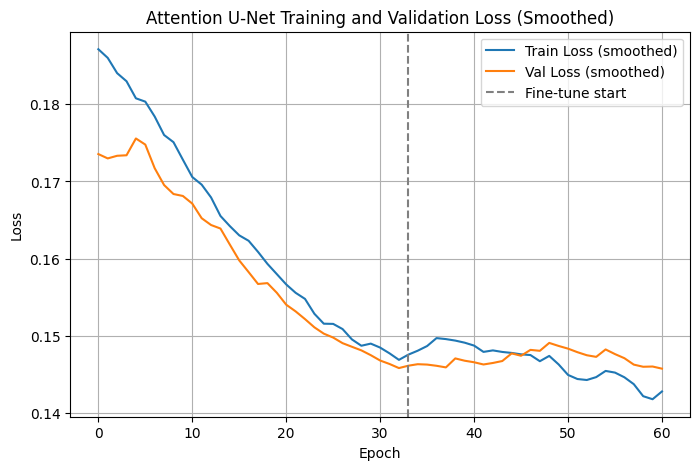

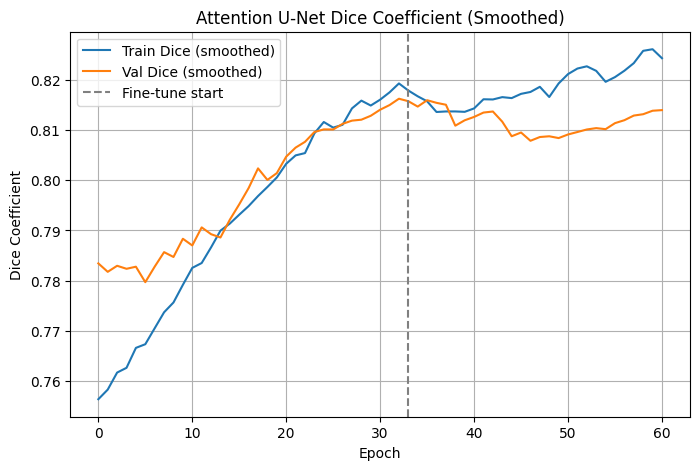

In [ ]:
def smooth(values, weight=0.85):
    smoothed = []
    last = values[0]
    for v in values:
        last = last * weight + (1 - weight) * v
        smoothed.append(last)
    return smoothed

# ---- Smoothed Loss curve ----
plt.figure(figsize=(8, 5))
plt.plot(smooth(full_history["loss"]), label="Train Loss (smoothed)", color="tab:blue")
plt.plot(smooth(full_history["val_loss"]), label="Val Loss (smoothed)", color="tab:orange")
plt.axvline(len(history.history["loss"]), color="gray", linestyle="--", label="Fine-tune start")
plt.title("Attention U-Net Training and Validation Loss (Smoothed)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(save_dir, "attention_unet_loss_curve_smoothed.png"), dpi=300, bbox_inches="tight")
plt.show()

# ---- Smoothed Dice curve ----
plt.figure(figsize=(8, 5))
plt.plot(smooth(full_history["dice_coef"]), label="Train Dice (smoothed)", color="tab:blue")
plt.plot(smooth(full_history["val_dice_coef"]), label="Val Dice (smoothed)", color="tab:orange")
plt.axvline(len(history.history["dice_coef"]), color="gray", linestyle="--", label="Fine-tune start")
plt.title("Attention U-Net Dice Coefficient (Smoothed)")
plt.xlabel("Epoch")
plt.ylabel("Dice Coefficient")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(save_dir, "attention_unet_dice_curve_smoothed.png"), dpi=300, bbox_inches="tight")
plt.show()

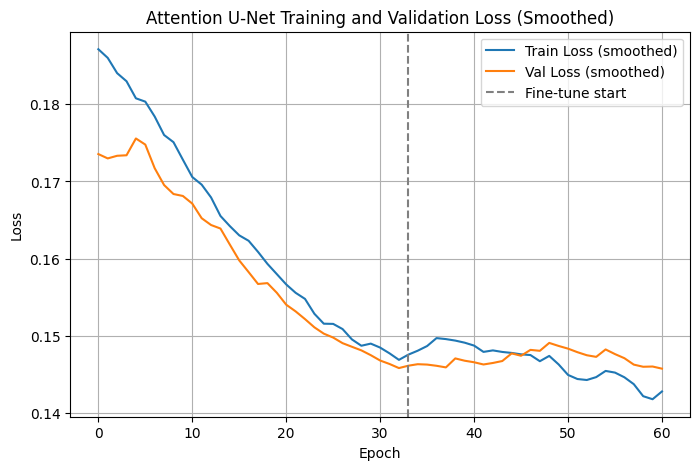

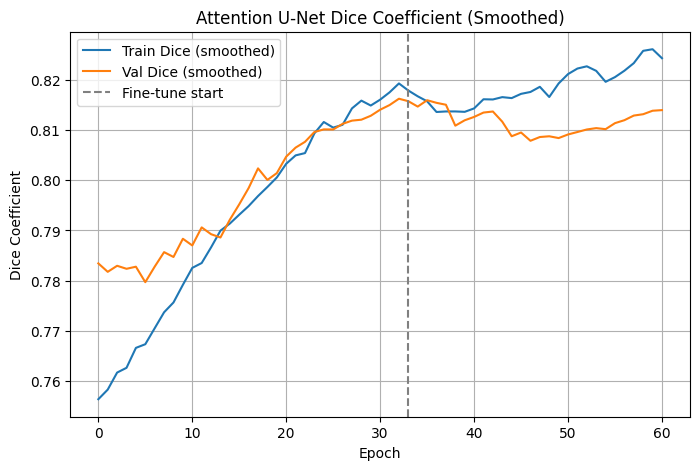

In [83]:
def smooth(values, weight=0.85):
    smoothed = []
    last = values[0]
    for v in values:
        last = last * weight + (1 - weight) * v
        smoothed.append(last)
    return smoothed

# ---- Smoothed Loss curve ----
plt.figure(figsize=(8, 5))
plt.plot(smooth(full_history["loss"]), label="Train Loss (smoothed)", color="tab:blue")
plt.plot(smooth(full_history["val_loss"]), label="Val Loss (smoothed)", color="tab:orange")
plt.axvline(len(history.history["loss"]), color="gray", linestyle="--", label="Fine-tune start")
plt.title("Attention U-Net Training and Validation Loss (Smoothed)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(save_dir, "attention_unet_loss_curve_smoothed.png"), dpi=300, bbox_inches="tight")
plt.show()

# ---- Smoothed Dice curve ----
plt.figure(figsize=(8, 5))
plt.plot(smooth(full_history["dice_coef"]), label="Train Dice (smoothed)", color="tab:blue")
plt.plot(smooth(full_history["val_dice_coef"]), label="Val Dice (smoothed)", color="tab:orange")
plt.axvline(len(history.history["dice_coef"]), color="gray", linestyle="--", label="Fine-tune start")
plt.title("Attention U-Net Dice Coefficient (Smoothed)")
plt.xlabel("Epoch")
plt.ylabel("Dice Coefficient")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(save_dir, "attention_unet_dice_curve_smoothed.png"), dpi=300, bbox_inches="tight")
plt.show()

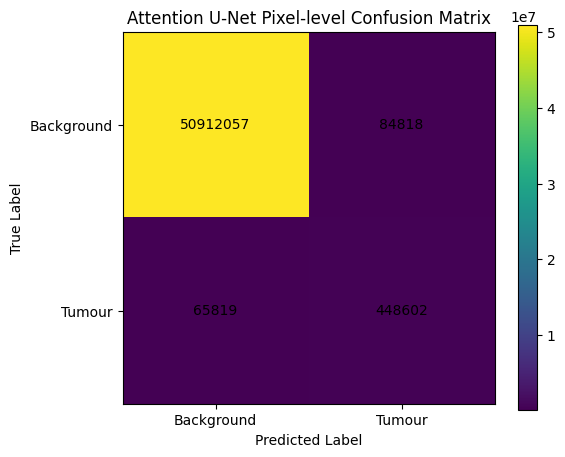

In [89]:
plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("Attention U-Net Pixel-level Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["Background", "Tumour"])
plt.yticks([0, 1], ["Background", "Tumour"])

plt.text(0, 0, cm[0, 0], ha="center", va="center")
plt.text(1, 0, cm[0, 1], ha="center", va="center")
plt.text(0, 1, cm[1, 0], ha="center", va="center")
plt.text(1, 1, cm[1, 1], ha="center", va="center")

plt.colorbar()
plt.show()

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
Prediction shape: (786, 256, 256, 1)
Ground truth shape: (786, 256, 256, 1)
========== FINAL TEST RESULTS ==========
Threshold: 0.5
Overall Dice: 0.8562
Overall IoU: 0.7486
Tumour-positive Dice: 0.8655
Tumour-positive IoU: 0.7629
Precision: 0.841
Recall: 0.8721
F1-score: 0.8562

Confusion Matrix:
[[50912057    84818]
 [   65819   448602]]

Classification Report:
              precision    recall  f1-score   support

  Background       1.00      1.00      1.00  50996875
      Tumour       0.84      0.87      0.86    514421

    accuracy                           1.00  51511296
   macro avg       0.92      0.94      0.93  51511296
weighted avg       1.00      1.00      1.00  51511296



,Model,Threshold,Overall Dice,Overall IoU,Tumour-positive Dice,Tumour-positive IoU,Precision,Recall,F1-score,True Negative,False Positive,False Negative,True Positive
0,Attention U-Net,0.5,0.856241,0.748619,0.865474,0.762851,0.840992,0.872052,0.856241,50912057,84818,65819,448602


Metrics saved at: /content/drive/MyDrive/brain_tumor_segmentation_results/final_attention_unet_metrics.csv


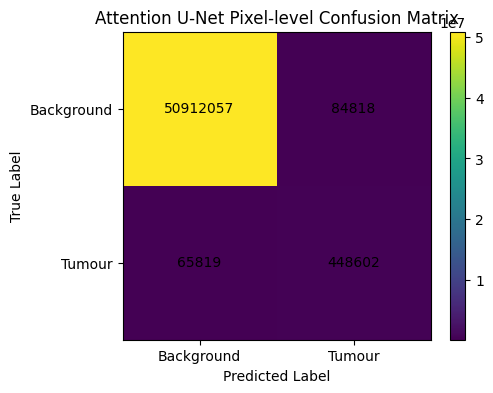

Confusion matrix saved at: /content/drive/MyDrive/brain_tumor_segmentation_results/attention_unet_confusion_matrix.png


In [91]:
# ============================================================
# FINAL METRICS + CONFUSION MATRIX FOR ATTENTION U-NET
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# ------------------------------------------------------------
# 1. Predict on test set
# ------------------------------------------------------------

test_pred = model.predict(X_test, batch_size=BATCH_SIZE)

threshold = 0.5

test_pred_binary = (test_pred > threshold).astype(np.uint8)
y_test_binary = (y_test > 0.5).astype(np.uint8)

print("Prediction shape:", test_pred_binary.shape)
print("Ground truth shape:", y_test_binary.shape)

# ------------------------------------------------------------
# 2. Dice and IoU functions
# ------------------------------------------------------------

def dice_numpy(y_true, y_pred, smooth=1e-6):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    intersection = np.sum(y_true * y_pred)

    return (2 * intersection + smooth) / (
        np.sum(y_true) + np.sum(y_pred) + smooth
    )

def iou_numpy(y_true, y_pred, smooth=1e-6):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    intersection = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - intersection

    return (intersection + smooth) / (union + smooth)

# ------------------------------------------------------------
# 3. Calculate Dice and IoU
# ------------------------------------------------------------

overall_dice = dice_numpy(y_test_binary, test_pred_binary)
overall_iou = iou_numpy(y_test_binary, test_pred_binary)

# Tumour-positive test images only
has_tumour = np.array([
    np.sum(y_test_binary[i]) > 0 for i in range(len(y_test_binary))
])

tumour_positive_dice = dice_numpy(
    y_test_binary[has_tumour],
    test_pred_binary[has_tumour]
)

tumour_positive_iou = iou_numpy(
    y_test_binary[has_tumour],
    test_pred_binary[has_tumour]
)

# ------------------------------------------------------------
# 4. Confusion matrix, precision, recall, F1
# ------------------------------------------------------------

y_true_flat = y_test_binary.flatten()
y_pred_flat = test_pred_binary.flatten()

cm = confusion_matrix(y_true_flat, y_pred_flat)

precision = precision_score(y_true_flat, y_pred_flat, zero_division=0)
recall = recall_score(y_true_flat, y_pred_flat, zero_division=0)
f1 = f1_score(y_true_flat, y_pred_flat, zero_division=0)

print("========== FINAL TEST RESULTS ==========")
print("Threshold:", threshold)
print("Overall Dice:", round(overall_dice, 4))
print("Overall IoU:", round(overall_iou, 4))
print("Tumour-positive Dice:", round(tumour_positive_dice, 4))
print("Tumour-positive IoU:", round(tumour_positive_iou, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))
print()
print("Confusion Matrix:")
print(cm)

print()
print("Classification Report:")
print(classification_report(
    y_true_flat,
    y_pred_flat,
    target_names=["Background", "Tumour"],
    zero_division=0
))

# ------------------------------------------------------------
# 5. Save metrics table
# ------------------------------------------------------------

final_metrics_df = pd.DataFrame({
    "Model": ["Attention U-Net"],
    "Threshold": [threshold],
    "Overall Dice": [overall_dice],
    "Overall IoU": [overall_iou],
    "Tumour-positive Dice": [tumour_positive_dice],
    "Tumour-positive IoU": [tumour_positive_iou],
    "Precision": [precision],
    "Recall": [recall],
    "F1-score": [f1],
    "True Negative": [cm[0, 0]],
    "False Positive": [cm[0, 1]],
    "False Negative": [cm[1, 0]],
    "True Positive": [cm[1, 1]]
})

metrics_path = os.path.join(save_dir, "final_attention_unet_metrics.csv")
final_metrics_df.to_csv(metrics_path, index=False)

display(final_metrics_df)

print("Metrics saved at:", metrics_path)

# ------------------------------------------------------------
# 6. Plot and save confusion matrix
# ------------------------------------------------------------

confusion_matrix_path = os.path.join(save_dir, "attention_unet_confusion_matrix.png")

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Attention U-Net Pixel-level Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["Background", "Tumour"])
plt.yticks([0, 1], ["Background", "Tumour"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.savefig(confusion_matrix_path, dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix saved at:", confusion_matrix_path)

In [92]:
# ============================================================
# FINAL TEST SAMPLE PREDICTIONS FOR ATTENTION U-NET
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

# Folder to save prediction images
prediction_dir = os.path.join(save_dir, "final_attention_unet_test_predictions")
os.makedirs(prediction_dir, exist_ok=True)

# ------------------------------------------------------------
# 1. Find tumour-positive test samples
# ------------------------------------------------------------

positive_test_indexes = []

for i in range(len(y_test_binary)):
    if np.sum(y_test_binary[i]) > 0:
        positive_test_indexes.append(i)

print("Total test samples:", len(y_test_binary))
print("Tumour-positive test samples:", len(positive_test_indexes))
print("First tumour-positive indexes:", positive_test_indexes[:10])

Total test samples: 786
Tumour-positive test samples: 275
First tumour-positive indexes: [1, 3, 6, 9, 10, 12, 17, 18, 21, 24]


In [93]:
# ============================================================
# 2. Calculate Dice score for each tumour-positive test sample
# ============================================================

def dice_single(y_true, y_pred, smooth=1e-6):
    y_true = y_true.squeeze().flatten()
    y_pred = y_pred.squeeze().flatten()

    intersection = np.sum(y_true * y_pred)

    return (2 * intersection + smooth) / (
        np.sum(y_true) + np.sum(y_pred) + smooth
    )

sample_dice_scores = []

for idx in positive_test_indexes:
    score = dice_single(y_test_binary[idx], test_pred_binary[idx])
    sample_dice_scores.append((idx, score))

# Sort from best to worst
sample_dice_scores_sorted = sorted(
    sample_dice_scores,
    key=lambda x: x[1],
    reverse=True
)

print("Top 10 best tumour-positive test samples:")
for idx, score in sample_dice_scores_sorted[:10]:
    print("Test index:", idx, "Dice:", round(score, 4))

Top 10 best tumour-positive test samples:
Test index: 284 Dice: 0.9813
Test index: 777 Dice: 0.9782
Test index: 325 Dice: 0.9765
Test index: 141 Dice: 0.9702
Test index: 21 Dice: 0.9698
Test index: 719 Dice: 0.9649
Test index: 768 Dice: 0.9644
Test index: 420 Dice: 0.9625
Test index: 419 Dice: 0.9618
Test index: 526 Dice: 0.9614


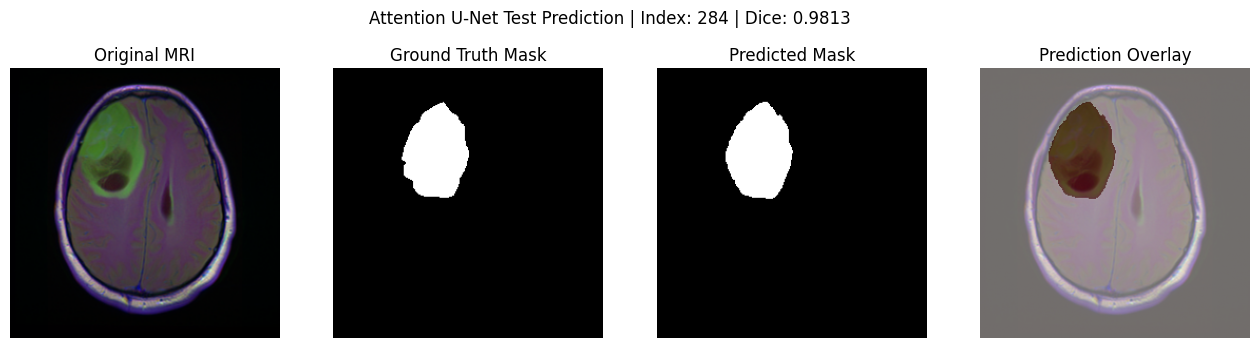

Saved: /content/drive/MyDrive/brain_tumor_segmentation_results/final_attention_unet_test_predictions/attention_unet_test_index_284_dice_0.9813.png


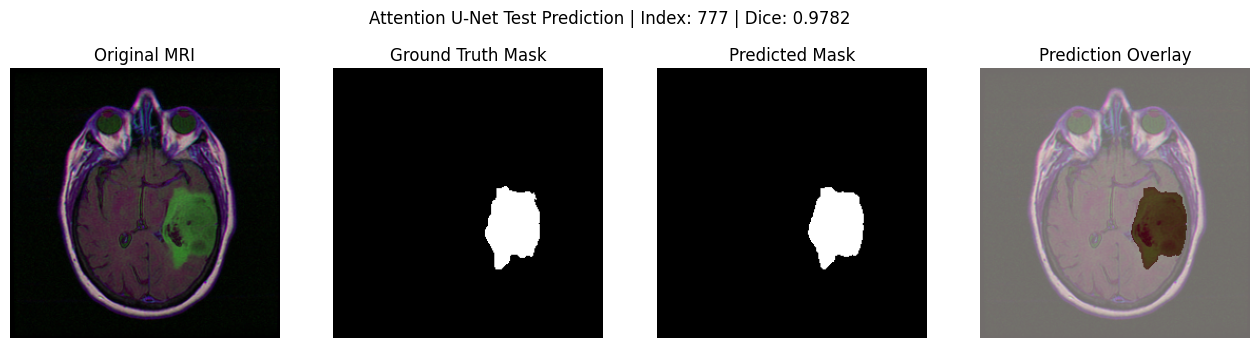

Saved: /content/drive/MyDrive/brain_tumor_segmentation_results/final_attention_unet_test_predictions/attention_unet_test_index_777_dice_0.9782.png


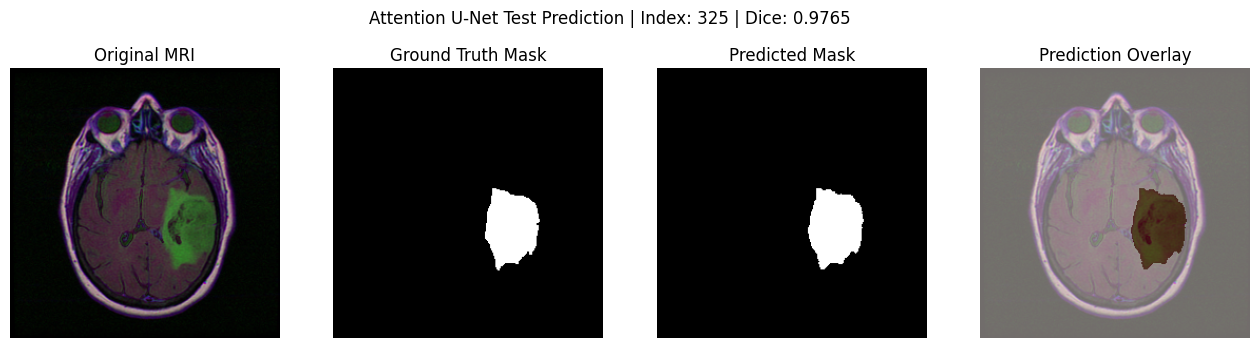

Saved: /content/drive/MyDrive/brain_tumor_segmentation_results/final_attention_unet_test_predictions/attention_unet_test_index_325_dice_0.9765.png


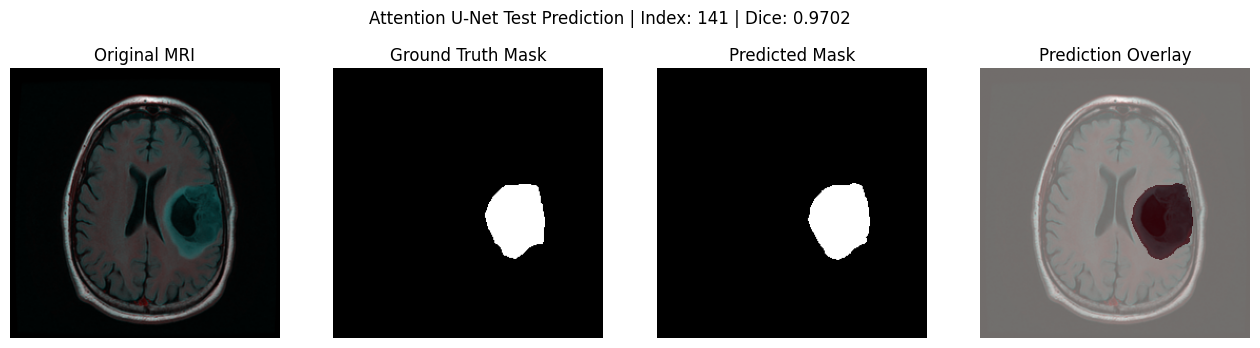

Saved: /content/drive/MyDrive/brain_tumor_segmentation_results/final_attention_unet_test_predictions/attention_unet_test_index_141_dice_0.9702.png


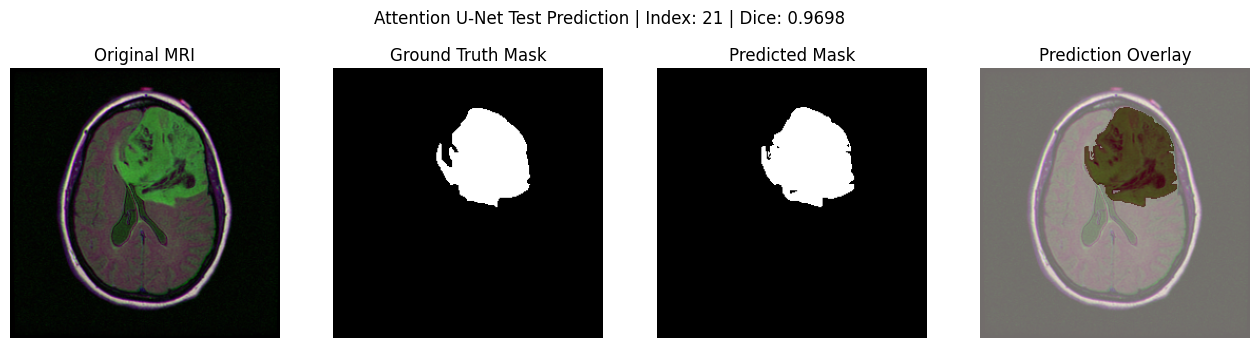

Saved: /content/drive/MyDrive/brain_tumor_segmentation_results/final_attention_unet_test_predictions/attention_unet_test_index_21_dice_0.9698.png


In [94]:
# ============================================================
# 3. Show and save best prediction examples
# ============================================================

def show_and_save_test_prediction(index, dice_score):
    plt.figure(figsize=(16, 4))

    # Original MRI
    plt.subplot(1, 4, 1)
    plt.imshow(X_test[index])
    plt.title("Original MRI")
    plt.axis("off")

    # Ground truth mask
    plt.subplot(1, 4, 2)
    plt.imshow(y_test_binary[index].squeeze(), cmap="gray")
    plt.title("Ground Truth Mask")
    plt.axis("off")

    # Predicted mask
    plt.subplot(1, 4, 3)
    plt.imshow(test_pred_binary[index].squeeze(), cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")

    # Overlay
    plt.subplot(1, 4, 4)
    plt.imshow(X_test[index])
    plt.imshow(test_pred_binary[index].squeeze(), cmap="Reds", alpha=0.45)
    plt.title("Prediction Overlay")
    plt.axis("off")

    plt.suptitle(
        f"Attention U-Net Test Prediction | Index: {index} | Dice: {dice_score:.4f}",
        fontsize=12
    )

    save_path = os.path.join(
        prediction_dir,
        f"attention_unet_test_index_{index}_dice_{dice_score:.4f}.png"
    )

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", save_path)


# Show best 5 examples
for idx, score in sample_dice_scores_sorted[:5]:
    show_and_save_test_prediction(idx, score)

In [96]:
# ============================================================
# FINAL TEST RESULTS ONLY - ATTENTION U-NET
# ============================================================

import os
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------------------
# 1. Predict on test data
# ------------------------------------------------------------

test_pred = model.predict(X_test, batch_size=BATCH_SIZE)

threshold = 0.5
test_pred_binary = (test_pred > threshold).astype(np.uint8)
y_test_binary = (y_test > 0.5).astype(np.uint8)

# ------------------------------------------------------------
# 2. Dice and IoU functions
# ------------------------------------------------------------

def dice_numpy(y_true, y_pred, smooth=1e-6):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    intersection = np.sum(y_true * y_pred)

    return (2 * intersection + smooth) / (
        np.sum(y_true) + np.sum(y_pred) + smooth
    )

def iou_numpy(y_true, y_pred, smooth=1e-6):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    intersection = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - intersection

    return (intersection + smooth) / (union + smooth)

# ------------------------------------------------------------
# 3. Calculate test metrics
# ------------------------------------------------------------

y_true_flat = y_test_binary.flatten()
y_pred_flat = test_pred_binary.flatten()

test_accuracy = accuracy_score(y_true_flat, y_pred_flat)
test_dice = dice_numpy(y_test_binary, test_pred_binary)
test_iou = iou_numpy(y_test_binary, test_pred_binary)
test_precision = precision_score(y_true_flat, y_pred_flat, zero_division=0)
test_recall = recall_score(y_true_flat, y_pred_flat, zero_division=0)
test_f1 = f1_score(y_true_flat, y_pred_flat, zero_division=0)

cm = confusion_matrix(y_true_flat, y_pred_flat)

# ------------------------------------------------------------
# 4. Print final test results
# ------------------------------------------------------------

print("========== FINAL TEST RESULTS ==========")
print("Model: Attention U-Net")
print("Threshold:", threshold)
print("Test Accuracy:", round(test_accuracy, 4))
print("Test Dice:", round(test_dice, 4))
print("Test IoU:", round(test_iou, 4))
print("Test Precision:", round(test_precision, 4))
print("Test Recall:", round(test_recall, 4))
print("Test F1-score:", round(test_f1, 4))
print()
print("Confusion Matrix:")
print(cm)

print()
print("Classification Report:")
print(classification_report(
    y_true_flat,
    y_pred_flat,
    target_names=["Background", "Tumour"],
    zero_division=0
))

# ------------------------------------------------------------
# 5. Save final test result table
# ------------------------------------------------------------

test_results_df = pd.DataFrame({
    "Model": ["Attention U-Net"],
    "Test Accuracy": [test_accuracy],
    "Test Dice": [test_dice],
    "Test IoU": [test_iou],
    "Test Precision": [test_precision],
    "Test Recall": [test_recall],
    "Test F1-score": [test_f1],
    "True Negative": [cm[0, 0]],
    "False Positive": [cm[0, 1]],
    "False Negative": [cm[1, 0]],
    "True Positive": [cm[1, 1]]
})

test_results_path = os.path.join(save_dir, "attention_unet_final_test_results.csv")
test_results_df.to_csv(test_results_path, index=False)

display(test_results_df)

print("Final test results saved at:", test_results_path)

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
========== FINAL TEST RESULTS ==========
Model: Attention U-Net
Threshold: 0.5
Test Accuracy: 0.9971
Test Dice: 0.8562
Test IoU: 0.7486
Test Precision: 0.841
Test Recall: 0.8721
Test F1-score: 0.8562

Confusion Matrix:
[[50912057    84818]
 [   65819   448602]]

Classification Report:
              precision    recall  f1-score   support

  Background       1.00      1.00      1.00  50996875
      Tumour       0.84      0.87      0.86    514421

    accuracy                           1.00  51511296
   macro avg       0.92      0.94      0.93  51511296
weighted avg       1.00      1.00      1.00  51511296



,Model,Test Accuracy,Test Dice,Test IoU,Test Precision,Test Recall,Test F1-score,True Negative,False Positive,False Negative,True Positive
0,Attention U-Net,0.997076,0.856241,0.748619,0.840992,0.872052,0.856241,50912057,84818,65819,448602


Final test results saved at: /content/drive/MyDrive/brain_tumor_segmentation_results/attention_unet_final_test_results.csv


In [97]:
# ============================================================
# TRAIN / VALIDATION / TEST METRICS - ATTENTION U-NET
# ============================================================

import os
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

threshold = 0.5

# ------------------------------------------------------------
# Dice and IoU functions
# ------------------------------------------------------------

def dice_numpy(y_true, y_pred, smooth=1e-6):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    intersection = np.sum(y_true * y_pred)

    return (2 * intersection + smooth) / (
        np.sum(y_true) + np.sum(y_pred) + smooth
    )

def iou_numpy(y_true, y_pred, smooth=1e-6):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    intersection = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - intersection

    return (intersection + smooth) / (union + smooth)

# ------------------------------------------------------------
# Function to evaluate one dataset
# ------------------------------------------------------------

def evaluate_dataset(model, X_data, y_data, dataset_name):
    print("Evaluating:", dataset_name)

    pred = model.predict(X_data, batch_size=BATCH_SIZE)

    pred_binary = (pred > threshold).astype(np.uint8)
    y_binary = (y_data > 0.5).astype(np.uint8)

    y_true_flat = y_binary.flatten()
    y_pred_flat = pred_binary.flatten()

    accuracy = accuracy_score(y_true_flat, y_pred_flat)
    dice = dice_numpy(y_binary, pred_binary)
    iou = iou_numpy(y_binary, pred_binary)
    precision = precision_score(y_true_flat, y_pred_flat, zero_division=0)
    recall = recall_score(y_true_flat, y_pred_flat, zero_division=0)
    f1 = f1_score(y_true_flat, y_pred_flat, zero_division=0)

    cm = confusion_matrix(y_true_flat, y_pred_flat)

    return {
        "Dataset": dataset_name,
        "Accuracy": accuracy,
        "Dice": dice,
        "IoU": iou,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "True Negative": cm[0, 0],
        "False Positive": cm[0, 1],
        "False Negative": cm[1, 0],
        "True Positive": cm[1, 1]
    }

# ------------------------------------------------------------
# Evaluate train, validation and test data
# ------------------------------------------------------------

train_metrics = evaluate_dataset(model, X_train, y_train, "Train")
val_metrics = evaluate_dataset(model, X_val, y_val, "Validation")
test_metrics = evaluate_dataset(model, X_test, y_test, "Test")

# ------------------------------------------------------------
# Create final table
# ------------------------------------------------------------

all_metrics_df = pd.DataFrame([
    train_metrics,
    val_metrics,
    test_metrics
])

display(all_metrics_df)

# ------------------------------------------------------------
# Save table to Drive
# ------------------------------------------------------------

all_metrics_path = os.path.join(save_dir, "attention_unet_train_val_test_metrics.csv")
all_metrics_df.to_csv(all_metrics_path, index=False)

print("Train/Validation/Test metrics saved at:", all_metrics_path)

Evaluating: Train
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step
Evaluating: Validation
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step
Evaluating: Test
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


,Dataset,Accuracy,Dice,IoU,Precision,Recall,F1-score,True Negative,False Positive,False Negative,True Positive
0,Train,0.997078,0.863339,0.759540,0.841712,0.886107,0.863339,162755122,286010,195483,1520889
1,Validation,0.996876,0.853750,0.744821,0.818167,0.892569,0.853750,40717558,83525,45235,375826
2,Test,0.997076,0.856241,0.748619,0.840992,0.872052,0.856241,50912057,84818,65819,448602


Train/Validation/Test metrics saved at: /content/drive/MyDrive/brain_tumor_segmentation_results/attention_unet_train_val_test_metrics.csv


In [ ]:
1. DeepLabV3-like comparison model

In [98]:
# ============================================================
# COMPARISON MODEL: LIGHTWEIGHT DEEPLABV3-LIKE MODEL
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, Activation,
    MaxPooling2D, UpSampling2D, Concatenate, Dropout
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
)

# ------------------------------------------------------------
# 1. Atrous / dilated convolution block
# ------------------------------------------------------------

def conv_bn_relu(x, filters, kernel_size=3, dilation_rate=1):
    x = Conv2D(
        filters,
        kernel_size,
        padding="same",
        dilation_rate=dilation_rate,
        use_bias=False
    )(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    return x


# ------------------------------------------------------------
# 2. ASPP block
# ------------------------------------------------------------

def aspp_block(x, filters):
    # Different dilation rates capture multi-scale context
    b1 = conv_bn_relu(x, filters, kernel_size=1, dilation_rate=1)
    b2 = conv_bn_relu(x, filters, kernel_size=3, dilation_rate=2)
    b3 = conv_bn_relu(x, filters, kernel_size=3, dilation_rate=4)
    b4 = conv_bn_relu(x, filters, kernel_size=3, dilation_rate=6)

    x = Concatenate()([b1, b2, b3, b4])
    x = conv_bn_relu(x, filters, kernel_size=1)
    x = Dropout(0.2)(x)

    return x


# ------------------------------------------------------------
# 3. Build lightweight DeepLabV3-like model
# ------------------------------------------------------------

def build_deeplabv3_like(input_shape):
    inputs = Input(input_shape)

    # Encoder
    x = conv_bn_relu(inputs, 32)
    x = MaxPooling2D((2, 2))(x)

    x = conv_bn_relu(x, 64)
    x = MaxPooling2D((2, 2))(x)

    x = conv_bn_relu(x, 128)
    x = MaxPooling2D((2, 2))(x)

    # ASPP / dilated convolution block
    x = aspp_block(x, 128)

    # Decoder
    x = UpSampling2D((2, 2), interpolation="bilinear")(x)
    x = conv_bn_relu(x, 64)

    x = UpSampling2D((2, 2), interpolation="bilinear")(x)
    x = conv_bn_relu(x, 32)

    x = UpSampling2D((2, 2), interpolation="bilinear")(x)
    x = conv_bn_relu(x, 16)

    outputs = Conv2D(1, 1, activation="sigmoid")(x)

    model = Model(inputs, outputs, name="DeepLabV3_like")
    return model


deeplab_model = build_deeplabv3_like((IMG_SIZE, IMG_SIZE, 3))

deeplab_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss=combo_loss,
    metrics=["accuracy", dice_coef, iou_metric]
)

deeplab_model.summary()

Model: "DeepLabV3_like"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_88 (Conv2D)  │ (None, 256, 256,  │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_88[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_76       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_16    │ (None, 128, 128,  │          0 │ activation_76[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_89 (Conv2D)  │ (None, 128, 128,  │     18,432 │ max_pooling2d_16… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_89[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_77       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_17    │ (None, 64, 64,    │          0 │ activation_77[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_90 (Conv2D)  │ (None, 64, 64,    │     73,728 │ max_pooling2d_17… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_90[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_78       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_18    │ (None, 32, 32,    │          0 │ activation_78[0]… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_91 (Conv2D)  │ (None, 32, 32,    │     16,384 │ max_pooling2d_18… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_92 (Conv2D)  │ (None, 32, 32,    │    147,456 │ max_pooling2d_18… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_93 (Conv2D)  │ (None, 32, 32,    │    147,456 │ max_pooling2d_18… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_94 (Conv2D)  │ (None, 32, 32,    │    147,456 │ max_pooling2d_18

 Total params: 718,001 (2.74 MB)

 Trainable params: 716,049 (2.73 MB)

 Non-trainable params: 1,952 (7.62 KB)

In [99]:
# ============================================================
# TRAIN DEEPLABV3-LIKE COMPARISON MODEL
# ============================================================

deeplab_best_path = os.path.join(save_dir, "best_deeplabv3_like.keras")
deeplab_last_path = os.path.join(save_dir, "last_deeplabv3_like.keras")
deeplab_history_path = os.path.join(save_dir, "deeplabv3_like_training_history.csv")

deeplab_callbacks = [
    ModelCheckpoint(
        filepath=deeplab_best_path,
        monitor="val_dice_coef",
        mode="max",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_dice_coef",
        mode="max",
        patience=12,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),

    CSVLogger(
        filename=deeplab_history_path,
        append=False
    )
]

deeplab_history = deeplab_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=60,
    callbacks=deeplab_callbacks
)

deeplab_model.save(deeplab_last_path)

print("Best DeepLabV3-like model saved at:", deeplab_best_path)
print("Last DeepLabV3-like model saved at:", deeplab_last_path)
print("Training history saved at:", deeplab_history_path)

Epoch 1/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.7693 - dice_coef: 0.0250 - iou_metric: 0.0127 - loss: 0.7726
Epoch 1: val_dice_coef improved from None to 0.02006, saving model to /content/drive/MyDrive/brain_tumor_segmentation_results/best_deeplabv3_like.keras

Epoch 1: finished saving model to /content/drive/MyDrive/brain_tumor_segmentation_results/best_deeplabv3_like.keras
158/158 ━━━━━━━━━━━━━━━━━━━━ 33s 115ms/step - accuracy: 0.8177 - dice_coef: 0.0289 - iou_metric: 0.0147 - loss: 0.7578 - val_accuracy: 0.9898 - val_dice_coef: 0.0201 - val_iou_metric: 0.0102 - val_loss: 0.7388 - learning_rate: 1.0000e-05
Epoch 2/60
157/158 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9252 - dice_coef: 0.0368 - iou_metric: 0.0188 - loss: 0.7245
Epoch 2: val_dice_coef improved from 0.02006 to 0.02458, saving model to /content/drive/MyDrive/brain_tumor_segmentation_results/best_deeplabv3_like.keras

Epoch 2: finished saving model to /content/drive/MyDrive/brain_tumor_segmentation

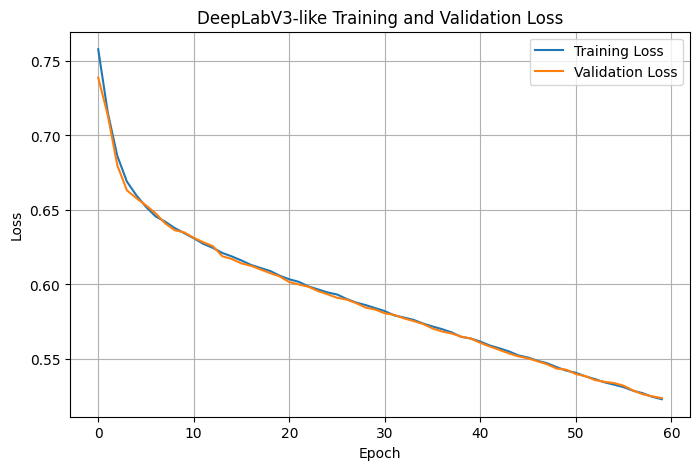

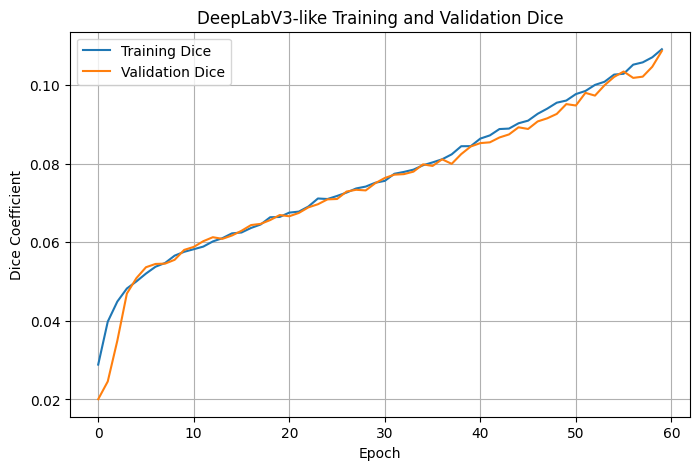

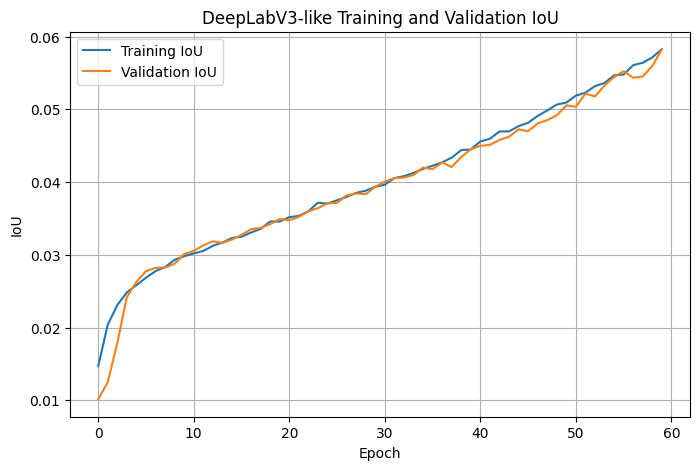

DeepLabV3-like curves saved in: /content/drive/MyDrive/brain_tumor_segmentation_results


In [102]:
# ============================================================
# DEEPLABV3-LIKE TRAINING CURVES
# ============================================================

deeplab_loss_curve_path = os.path.join(save_dir, "deeplabv3_like_loss_curve.png")
deeplab_dice_curve_path = os.path.join(save_dir, "deeplabv3_like_dice_curve.png")
deeplab_iou_curve_path = os.path.join(save_dir, "deeplabv3_like_iou_curve.png")

# Loss curve
plt.figure(figsize=(8, 5))
plt.plot(deeplab_history.history["loss"], label="Training Loss")
plt.plot(deeplab_history.history["val_loss"], label="Validation Loss")
plt.title("DeepLabV3-like Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig(deeplab_loss_curve_path, dpi=300, bbox_inches="tight")
plt.show()

# Dice curve
plt.figure(figsize=(8, 5))
plt.plot(deeplab_history.history["dice_coef"], label="Training Dice")
plt.plot(deeplab_history.history["val_dice_coef"], label="Validation Dice")
plt.title("DeepLabV3-like Training and Validation Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice Coefficient")
plt.legend()
plt.grid(True)
plt.savefig(deeplab_dice_curve_path, dpi=300, bbox_inches="tight")
plt.show()

# IoU curve
plt.figure(figsize=(8, 5))
plt.plot(deeplab_history.history["iou_metric"], label="Training IoU")
plt.plot(deeplab_history.history["val_iou_metric"], label="Validation IoU")
plt.title("DeepLabV3-like Training and Validation IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.legend()
plt.grid(True)
plt.savefig(deeplab_iou_curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("DeepLabV3-like curves saved in:", save_dir)

In [103]:
# ============================================================
# FINAL TEST METRICS FOR DEEPLABV3-LIKE MODEL
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Load best DeepLabV3-like model
deeplab_model = tf.keras.models.load_model(
    deeplab_best_path,
    custom_objects={
        "combo_loss": combo_loss,
        "focal_tversky_loss": focal_tversky_loss,
        "dice_coef": dice_coef,
        "iou_metric": iou_metric
    }
)

print("Loaded best DeepLabV3-like model:", deeplab_best_path)

# Evaluate
deeplab_eval = deeplab_model.evaluate(X_test, y_test, batch_size=BATCH_SIZE, verbose=1)

# Predict
deeplab_pred = deeplab_model.predict(X_test, batch_size=BATCH_SIZE)

threshold = 0.5

deeplab_pred_binary = (deeplab_pred > threshold).astype(np.uint8)
y_test_binary = (y_test > 0.5).astype(np.uint8)

# Metrics
deeplab_overall_dice = dice_numpy(y_test_binary, deeplab_pred_binary)
deeplab_overall_iou = iou_numpy(y_test_binary, deeplab_pred_binary)

has_tumour = np.array([
    np.sum(y_test_binary[i]) > 0 for i in range(len(y_test_binary))
])

deeplab_tumour_dice = dice_numpy(
    y_test_binary[has_tumour],
    deeplab_pred_binary[has_tumour]
)

deeplab_tumour_iou = iou_numpy(
    y_test_binary[has_tumour],
    deeplab_pred_binary[has_tumour]
)

y_true_flat = y_test_binary.flatten()
y_pred_flat = deeplab_pred_binary.flatten()

deeplab_accuracy = accuracy_score(y_true_flat, y_pred_flat)
deeplab_precision = precision_score(y_true_flat, y_pred_flat, zero_division=0)
deeplab_recall = recall_score(y_true_flat, y_pred_flat, zero_division=0)
deeplab_f1 = f1_score(y_true_flat, y_pred_flat, zero_division=0)

deeplab_cm = confusion_matrix(y_true_flat, y_pred_flat)

print("========== DEEPLABV3-LIKE TEST RESULTS ==========")
print("Threshold:", threshold)
print("Test Accuracy:", round(deeplab_accuracy, 4))
print("Overall Dice:", round(deeplab_overall_dice, 4))
print("Overall IoU:", round(deeplab_overall_iou, 4))
print("Tumour-positive Dice:", round(deeplab_tumour_dice, 4))
print("Tumour-positive IoU:", round(deeplab_tumour_iou, 4))
print("Precision:", round(deeplab_precision, 4))
print("Recall:", round(deeplab_recall, 4))
print("F1-score:", round(deeplab_f1, 4))
print("Confusion Matrix:")
print(deeplab_cm)

print()
print("Classification Report:")
print(classification_report(
    y_true_flat,
    y_pred_flat,
    target_names=["Background", "Tumour"],
    zero_division=0
))

# Save metrics
deeplab_metrics_df = pd.DataFrame({
    "Model": ["DeepLabV3-like"],
    "Threshold": [threshold],
    "Test Accuracy": [deeplab_accuracy],
    "Overall Dice": [deeplab_overall_dice],
    "Overall IoU": [deeplab_overall_iou],
    "Tumour-positive Dice": [deeplab_tumour_dice],
    "Tumour-positive IoU": [deeplab_tumour_iou],
    "Precision": [deeplab_precision],
    "Recall": [deeplab_recall],
    "F1-score": [deeplab_f1],
    "True Negative": [deeplab_cm[0, 0]],
    "False Positive": [deeplab_cm[0, 1]],
    "False Negative": [deeplab_cm[1, 0]],
    "True Positive": [deeplab_cm[1, 1]]
})

deeplab_metrics_path = os.path.join(save_dir, "final_deeplabv3_like_metrics.csv")
deeplab_metrics_df.to_csv(deeplab_metrics_path, index=False)

display(deeplab_metrics_df)

print("DeepLabV3-like metrics saved at:", deeplab_metrics_path)

Loaded best DeepLabV3-like model: /content/drive/MyDrive/brain_tumor_segmentation_results/best_deeplabv3_like.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.9953 - dice_coef: 0.1098 - iou_metric: 0.0590 - loss: 0.5221
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step
========== DEEPLABV3-LIKE TEST RESULTS ==========
Threshold: 0.5
Test Accuracy: 0.9953
Overall Dice: 0.7993
Overall IoU: 0.6656
Tumour-positive Dice: 0.818
Tumour-positive IoU: 0.6921
Precision: 0.7003
Recall: 0.9307
F1-score: 0.7993
Confusion Matrix:
[[50791996   204879]
 [   35632   478789]]

Classification Report:
              precision    recall  f1-score   support

  Background       1.00      1.00      1.00  50996875
      Tumour       0.70      0.93      0.80    514421

    accuracy                           1.00  51511296
   macro avg       0.85      0.96      0.90  51511296
weighted avg       1.00      1.00      1.00  51511296



,Model,Threshold,Test Accuracy,Overall Dice,Overall IoU,Tumour-positive Dice,Tumour-positive IoU,Precision,Recall,F1-score,True Negative,False Positive,False Negative,True Positive
0,DeepLabV3-like,0.5,0.995331,0.799254,0.665632,0.818021,0.692078,0.700324,0.930734,0.799254,50791996,204879,35632,478789


DeepLabV3-like metrics saved at: /content/drive/MyDrive/brain_tumor_segmentation_results/final_deeplabv3_like_metrics.csv


Top 10 DeepLabV3-like tumour-positive test samples:
Index: 584 Dice: 0.9434
Index: 24 Dice: 0.9403
Index: 131 Dice: 0.9394
Index: 21 Dice: 0.9348
Index: 243 Dice: 0.9326
Index: 145 Dice: 0.9307
Index: 141 Dice: 0.9242
Index: 505 Dice: 0.9214
Index: 296 Dice: 0.9209
Index: 357 Dice: 0.9187


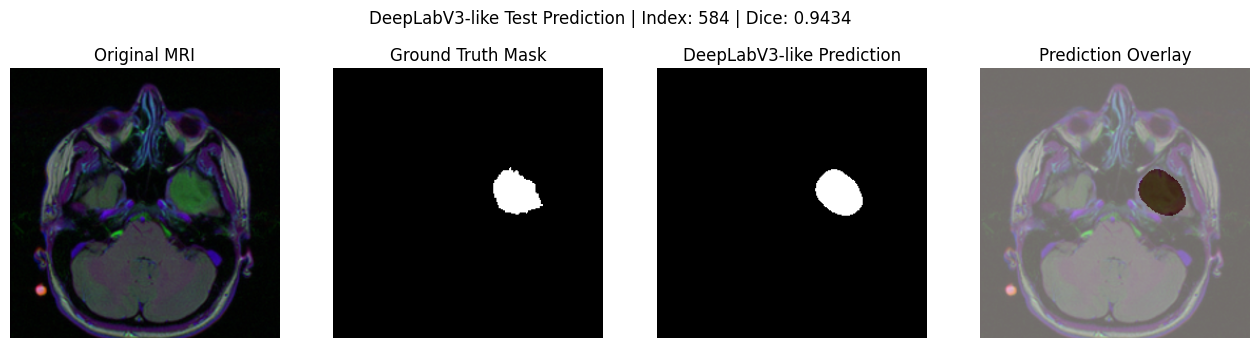

Saved: /content/drive/MyDrive/brain_tumor_segmentation_results/deeplabv3_like_test_predictions/deeplabv3_like_test_index_584_dice_0.9434.png


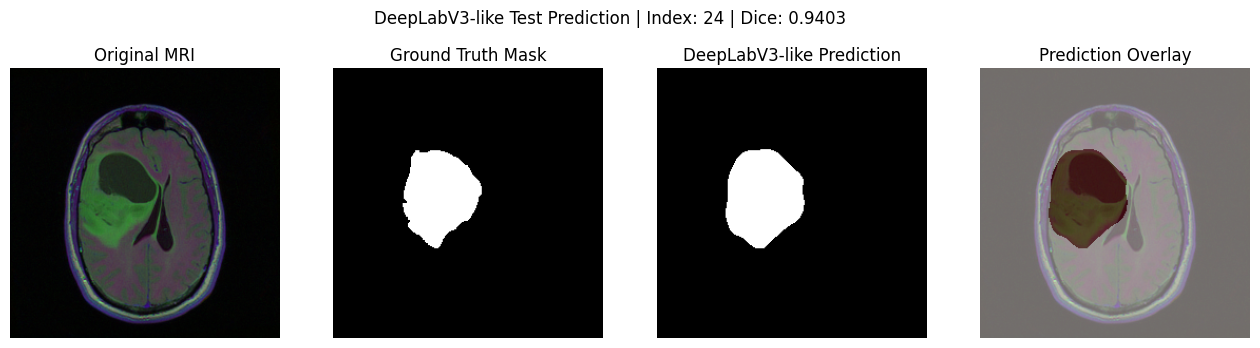

Saved: /content/drive/MyDrive/brain_tumor_segmentation_results/deeplabv3_like_test_predictions/deeplabv3_like_test_index_24_dice_0.9403.png


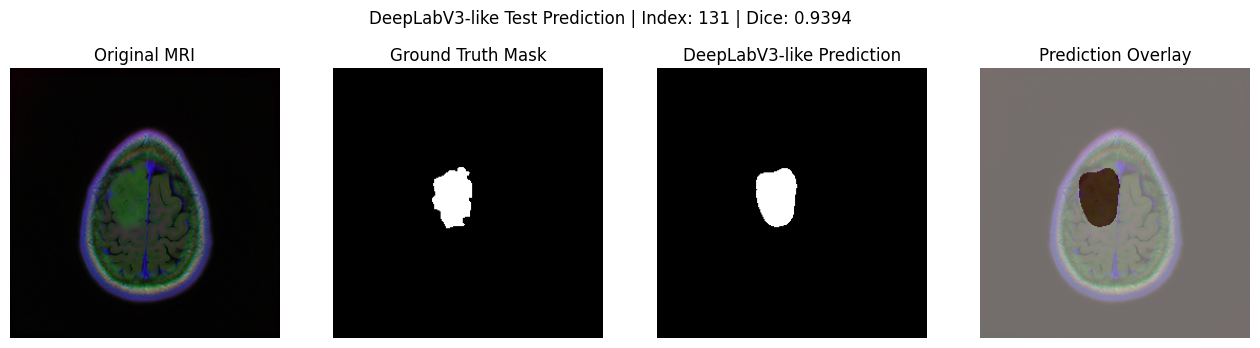

Saved: /content/drive/MyDrive/brain_tumor_segmentation_results/deeplabv3_like_test_predictions/deeplabv3_like_test_index_131_dice_0.9394.png


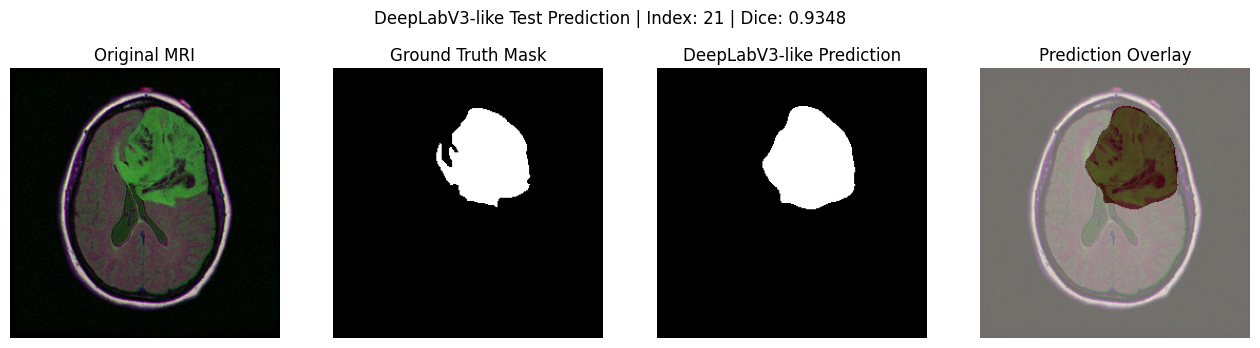

Saved: /content/drive/MyDrive/brain_tumor_segmentation_results/deeplabv3_like_test_predictions/deeplabv3_like_test_index_21_dice_0.9348.png


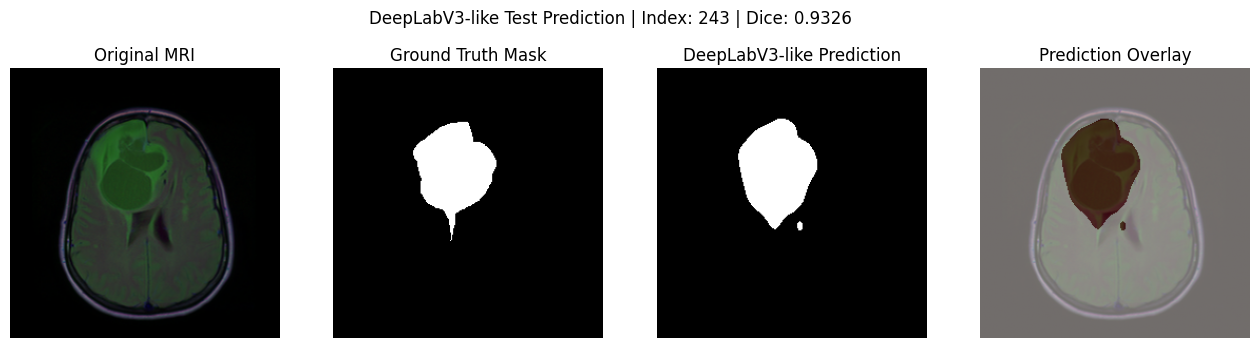

Saved: /content/drive/MyDrive/brain_tumor_segmentation_results/deeplabv3_like_test_predictions/deeplabv3_like_test_index_243_dice_0.9326.png


In [104]:
# ============================================================
# DEEPLABV3-LIKE TEST SAMPLE PREDICTIONS
# ============================================================

deeplab_prediction_dir = os.path.join(save_dir, "deeplabv3_like_test_predictions")
os.makedirs(deeplab_prediction_dir, exist_ok=True)

positive_test_indexes = []

for i in range(len(y_test_binary)):
    if np.sum(y_test_binary[i]) > 0:
        positive_test_indexes.append(i)

def dice_single(y_true, y_pred, smooth=1e-6):
    y_true = y_true.squeeze().flatten()
    y_pred = y_pred.squeeze().flatten()

    intersection = np.sum(y_true * y_pred)

    return (2 * intersection + smooth) / (
        np.sum(y_true) + np.sum(y_pred) + smooth
    )

deeplab_sample_scores = []

for idx in positive_test_indexes:
    score = dice_single(y_test_binary[idx], deeplab_pred_binary[idx])
    deeplab_sample_scores.append((idx, score))

deeplab_sample_scores_sorted = sorted(
    deeplab_sample_scores,
    key=lambda x: x[1],
    reverse=True
)

print("Top 10 DeepLabV3-like tumour-positive test samples:")
for idx, score in deeplab_sample_scores_sorted[:10]:
    print("Index:", idx, "Dice:", round(score, 4))

def show_deeplab_prediction(index, dice_score):
    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(X_test[index])
    plt.title("Original MRI")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(y_test_binary[index].squeeze(), cmap="gray")
    plt.title("Ground Truth Mask")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(deeplab_pred_binary[index].squeeze(), cmap="gray")
    plt.title("DeepLabV3-like Prediction")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(X_test[index])
    plt.imshow(deeplab_pred_binary[index].squeeze(), cmap="Reds", alpha=0.45)
    plt.title("Prediction Overlay")
    plt.axis("off")

    plt.suptitle(
        f"DeepLabV3-like Test Prediction | Index: {index} | Dice: {dice_score:.4f}",
        fontsize=12
    )

    save_path = os.path.join(
        deeplab_prediction_dir,
        f"deeplabv3_like_test_index_{index}_dice_{dice_score:.4f}.png"
    )

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", save_path)


for idx, score in deeplab_sample_scores_sorted[:5]:
    show_deeplab_prediction(idx, score)

In [106]:
# ============================================================
# FINAL PRACTICAL MODEL COMPARISON TABLE
# Only models actually trained are included here
# ============================================================

comparison_df = pd.DataFrame({
    "Model": [
        "Attention U-Net",
        "DeepLabV3-like"
    ],
    "Status": [
        "Implemented and trained",
        "Implemented and trained"
    ],
    "Test Accuracy": [
        test_accuracy,
        deeplab_accuracy
    ],
    "Overall Dice": [
        overall_dice,
        deeplab_overall_dice
    ],
    "Overall IoU": [
        overall_iou,
        deeplab_overall_iou
    ],
    "Tumour-positive Dice": [
        tumour_positive_dice,
        deeplab_tumour_dice
    ],
    "Tumour-positive IoU": [
        tumour_positive_iou,
        deeplab_tumour_iou
    ],
    "Precision": [
        precision,
        deeplab_precision
    ],
    "Recall": [
        recall,
        deeplab_recall
    ],
    "F1-score": [
        f1,
        deeplab_f1
    ]
})

comparison_path = os.path.join(save_dir, "final_practical_model_comparison_table.csv")
comparison_df.to_csv(comparison_path, index=False)

display(comparison_df)

print("Final practical model comparison table saved at:", comparison_path)

,Model,Status,Test Accuracy,Overall Dice,Overall IoU,Tumour-positive Dice,Tumour-positive IoU,Precision,Recall,F1-score
0,Attention U-Net,Implemented and trained,0.997076,0.856241,0.748619,0.865474,0.762851,0.840992,0.872052,0.856241
1,DeepLabV3-like,Implemented and trained,0.995331,0.799254,0.665632,0.818021,0.692078,0.700324,0.930734,0.799254


Final practical model comparison table saved at: /content/drive/MyDrive/brain_tumor_segmentation_results/final_practical_model_comparison_table.csv
